
Current Training Status:
Total Epochs: 28
Train Acc: 56.33%
Val Acc: 56.14%

Phase 2 - Epoch 14/15
----------------------------------------------------------------------


Validation: 100%|██████████| 22/22 [00:00<00:00, 35.25it/s]



Results:
  Train Loss: 1.8595 | Train Acc: 56.64%
  Val Loss:   1.8886 | Val Acc:   55.57%

Phase 2 - Epoch 15/15
----------------------------------------------------------------------


Validation: 100%|██████████| 22/22 [00:00<00:00, 34.03it/s]



Results:
  Train Loss: 1.8212 | Train Acc: 56.43%
  Val Loss:   1.8825 | Val Acc:   56.43%
  Best model saved! (Val Acc: 56.43%)

Phase 2 complete! Time: 2.5 min
Total training time: 4.0 minutes
Best val accuracy: 56.43%

EVALUATION
Loaded best model
Val accuracy: 56.43%

Evaluating on test set...


...


TEST SET RESULTS
Test Loss:     1.9064
Test Accuracy: 0.5460 (54.60%)


Predicting: 100%|██████████| 23/23 [00:00<00:00, 35.56it/s]


Top-5 Accuracy: 0.7799 (77.99%)

Extracting embeddings for test set...


Extracting: 100%|██████████| 23/23 [00:00<00:00, 36.62it/s]


Embeddings extracted: (718, 512)

Computing verification statistics...

Face Verification Statistics:
  Same person - Mean: 0.4671
  Different person - Mean: 0.9960
  Separation: 0.5289

Per-Identity Statistics:
  Mean accuracy: 0.2764
  Median accuracy: 0.0000
  Min accuracy: 0.0000
  Max accuracy: 1.0000


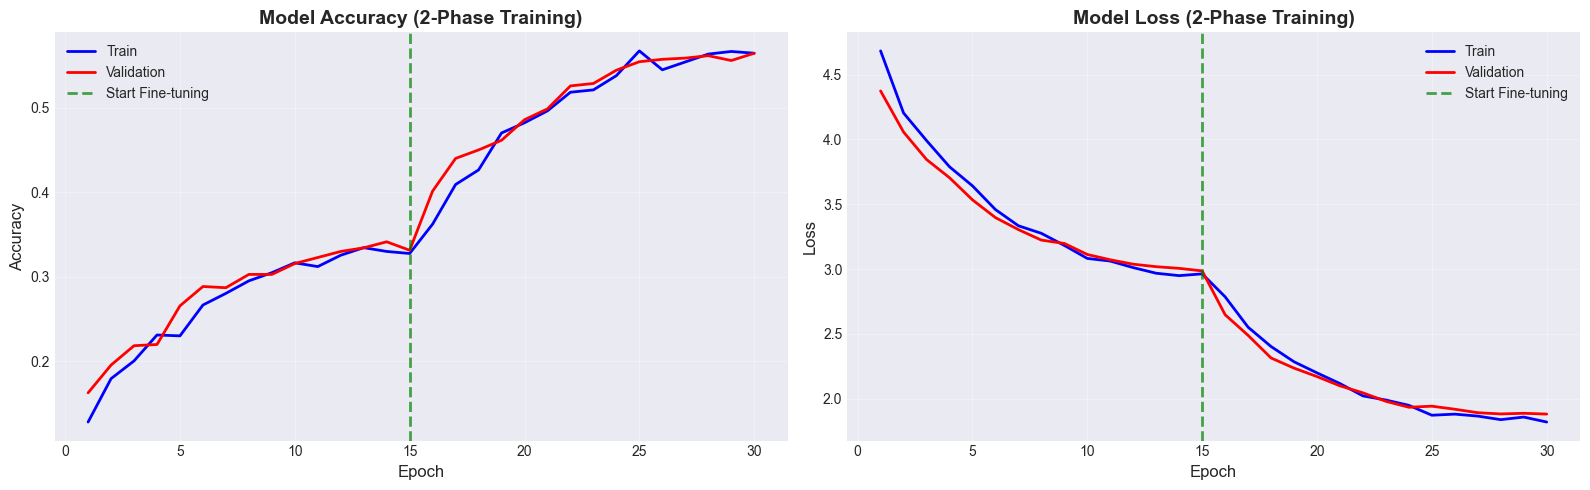

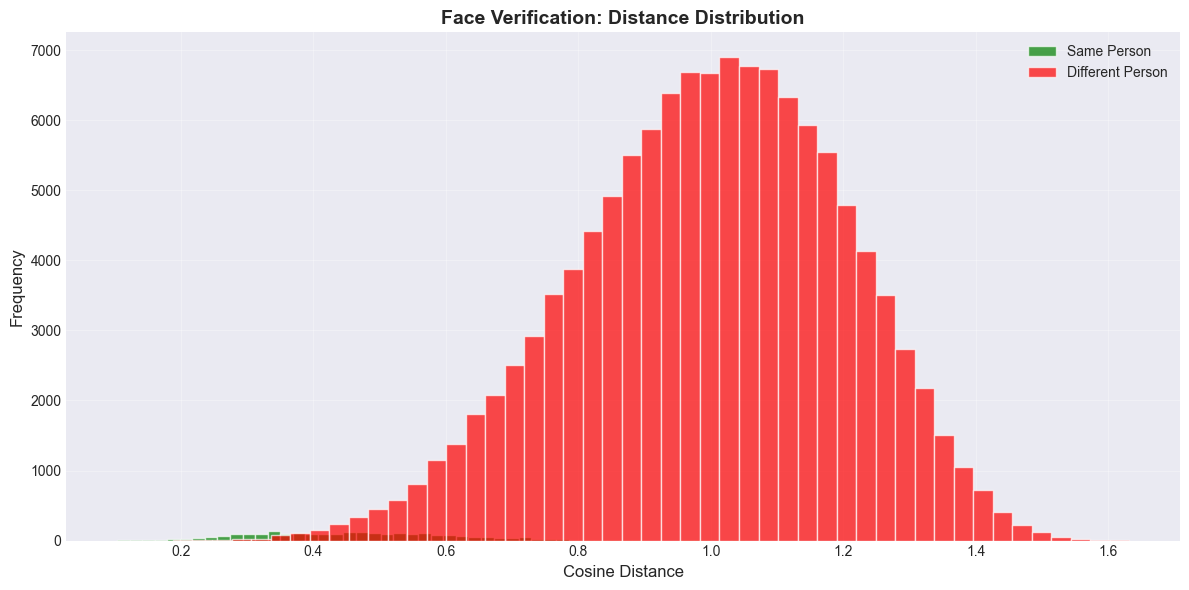

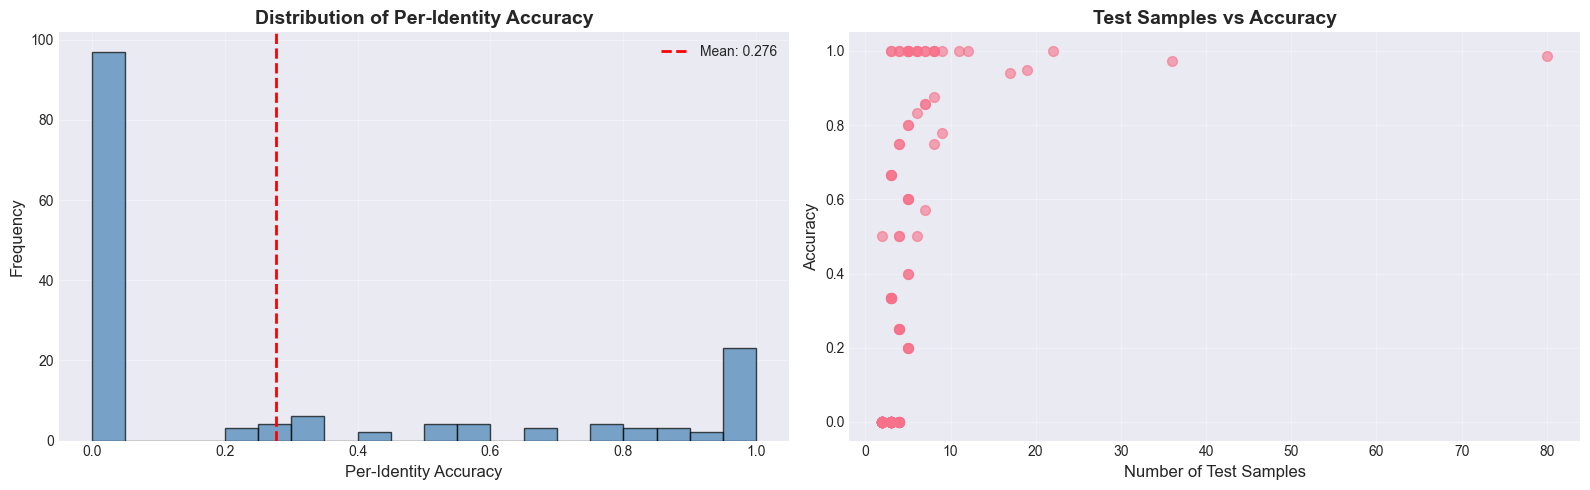


Model saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models\face_pytorch.pth
Embeddings saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch\test_embeddings.npy
History saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch\training_history.csv
Model info saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch\model_info.json

ALL DONE
Test Accuracy: 54.60%
Top-5 Accuracy: 77.99%
Total Training Time: 4.0 minutes
Model saved to: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models
Results saved to: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
from datetime import datetime
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image as PILImage

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

try:
    from IPython.display import clear_output
    JUPYTER_MODE = True
except:
    JUPYTER_MODE = False

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


class FaceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        image = (image * 255).astype(np.uint8)
        image = PILImage.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label


class FaceRecognitionNet(nn.Module):
    def __init__(self, num_classes, embedding_dim=512):
        super(FaceRecognitionNet, self).__init__()
        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.embedding = nn.Sequential(
            nn.Linear(num_features, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(embedding_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, return_embedding=False):
        features = self.backbone(x)
        embeddings = self.embedding(features)
        embeddings_norm = nn.functional.normalize(embeddings, p=2, dim=1)
        if return_embedding:
            return embeddings_norm
        output = self.classifier(embeddings_norm)
        return output


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


def plot_training_progress(history_combined, phase1_epochs, results_dir):
    if JUPYTER_MODE:
        clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    epochs_range = range(1, len(history_combined['train_acc']) + 1)

    axes[0].plot(epochs_range, history_combined['train_acc'], 'b-', label='Train', linewidth=2)
    axes[0].plot(epochs_range, history_combined['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[0].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                    label='Start Fine-tuning', alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Model Accuracy (2-Phase Training)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history_combined['train_loss'], 'b-', label='Train', linewidth=2)
    axes[1].plot(epochs_range, history_combined['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                    label='Start Fine-tuning', alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Model Loss (2-Phase Training)', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(results_dir / 'training_progress_live.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nCurrent Training Status:")
    print(f"Total Epochs: {len(history_combined['train_acc'])}")
    print(f"Train Acc: {history_combined['train_acc'][-1]*100:.2f}%")
    print(f"Val Acc: {history_combined['val_acc'][-1]*100:.2f}%")


def main():
    np.random.seed(42)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch: {torch.__version__}")
    print(f"Device: {device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"CUDA: {torch.version.cuda}")

    PROCESSED_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\data\processed\faces")
    MODELS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models")
    MODELS_DIR.mkdir(exist_ok=True)
    RESULTS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch")
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    BATCH_SIZE = 32
    EPOCHS_PHASE1 = 15
    EPOCHS_PHASE2 = 15
    LEARNING_RATE = 0.001
    FINETUNE_LR = 0.0001
    EMBEDDING_DIM = 512
    NUM_WORKERS = 0

    print(f"\nConfiguration:")
    print(f"  Device: {device}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Phase 1 epochs: {EPOCHS_PHASE1}")
    print(f"  Phase 2 epochs: {EPOCHS_PHASE2}")
    print(f"  Embedding dim: {EMBEDDING_DIM}")

    print("\n" + "="*70)
    print("LOADING DATA")
    print("="*70)

    X_train = np.load(PROCESSED_DIR / 'X_train.npy')
    y_train = np.load(PROCESSED_DIR / 'y_train.npy')
    X_val = np.load(PROCESSED_DIR / 'X_val.npy')
    y_val = np.load(PROCESSED_DIR / 'y_val.npy')
    X_test = np.load(PROCESSED_DIR / 'X_test.npy')
    y_test = np.load(PROCESSED_DIR / 'y_test.npy')

    with open(PROCESSED_DIR / 'label_mapping.pkl', 'rb') as f:
        label_mapping = pickle.load(f)

    NUM_CLASSES = label_mapping['num_classes']
    id_to_person = label_mapping['id_to_person']
    person_to_id = label_mapping['person_to_id']

    print(f"\nLoaded:")
    print(f"  Train: {X_train.shape}")
    print(f"  Val:   {X_val.shape}")
    print(f"  Test:  {X_test.shape}")
    print(f"  Identities: {NUM_CLASSES}")
    print(f"  Value range: [{X_train.min():.2f}, {X_train.max():.2f}]")

    X_train = (X_train + 1) / 2
    X_val = (X_val + 1) / 2
    X_test = (X_test + 1) / 2

    print(f"Data rescaled to [0, 1]")

    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
    val_dataset = FaceDataset(X_val, y_val, transform=val_transform)
    test_dataset = FaceDataset(X_test, y_test, transform=val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    print(f"\nData loaders created:")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}")

    model = FaceRecognitionNet(num_classes=NUM_CLASSES, embedding_dim=EMBEDDING_DIM).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'='*70}")
    print(f"MODEL CREATED")
    print(f"{'='*70}")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Embedding dimension: {EMBEDDING_DIM}")
    print(f"{'='*70}")

    print(f"\n{'='*70}")
    print(f"PHASE 1: TRAINING WITH FROZEN BACKBONE")
    print(f"{'='*70}")

    for param in model.backbone.parameters():
        param.requires_grad = False

    trainable_params_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params_p1:,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PHASE1, eta_min=1e-6)

    history_p1 = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc_p1 = 0.0
    start_time_p1 = datetime.now()

    for epoch in range(EPOCHS_PHASE1):
        print(f"\nPhase 1 - Epoch {epoch+1}/{EPOCHS_PHASE1}")
        print("-" * 70)

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        history_p1['train_loss'].append(train_loss)
        history_p1['train_acc'].append(train_acc)
        history_p1['val_loss'].append(val_loss)
        history_p1['val_acc'].append(val_acc)

        print(f"\nResults:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

        if val_acc > best_val_acc_p1:
            best_val_acc_p1 = val_acc
            print(f"  Best model (Phase 1)!")

        if epoch % 3 == 0:
            history_combined = {
                'train_loss': history_p1['train_loss'],
                'train_acc': history_p1['train_acc'],
                'val_loss': history_p1['val_loss'],
                'val_acc': history_p1['val_acc']
            }
            plot_training_progress(history_combined, EPOCHS_PHASE1, RESULTS_DIR)

    time_p1 = (datetime.now() - start_time_p1).total_seconds() / 60
    print(f"\nPhase 1 complete! Time: {time_p1:.1f} min, Best val acc: {best_val_acc_p1*100:.2f}%")

    print(f"\n{'='*70}")
    print(f"PHASE 2: FINE-TUNING")
    print(f"{'='*70}")

    for param in model.backbone.parameters():
        param.requires_grad = True

    trainable_params_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params_p2:,}")

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=FINETUNE_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PHASE2, eta_min=1e-7)

    history_p2 = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc_p2 = best_val_acc_p1
    patience = 8
    patience_counter = 0
    start_time_p2 = datetime.now()

    for epoch in range(EPOCHS_PHASE2):
        print(f"\nPhase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2}")
        print("-" * 70)

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        history_p2['train_loss'].append(train_loss)
        history_p2['train_acc'].append(train_acc)
        history_p2['val_loss'].append(val_loss)
        history_p2['val_acc'].append(val_acc)

        print(f"\nResults:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

        if val_acc > best_val_acc_p2:
            best_val_acc_p2 = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc,
                'epoch': epoch
            }, MODELS_DIR / 'face_pytorch_best.pth')
            print(f"  Best model saved! (Val Acc: {val_acc*100:.2f}%)")
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered")
            break

        if epoch % 3 == 0:
            history_combined = {
                'train_loss': history_p1['train_loss'] + history_p2['train_loss'],
                'train_acc': history_p1['train_acc'] + history_p2['train_acc'],
                'val_loss': history_p1['val_loss'] + history_p2['val_loss'],
                'val_acc': history_p1['val_acc'] + history_p2['val_acc']
            }
            plot_training_progress(history_combined, EPOCHS_PHASE1, RESULTS_DIR)

    time_p2 = (datetime.now() - start_time_p2).total_seconds() / 60
    total_time = time_p1 + time_p2

    print(f"\nPhase 2 complete! Time: {time_p2:.1f} min")
    print(f"Total training time: {total_time:.1f} minutes")
    print(f"Best val accuracy: {best_val_acc_p2*100:.2f}%")

    print(f"\n{'='*70}")
    print(f"EVALUATION")
    print(f"{'='*70}")

    checkpoint = torch.load(MODELS_DIR / 'face_pytorch_best.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model")
    print(f"Val accuracy: {checkpoint['val_acc']*100:.2f}%")

    print(f"\nEvaluating on test set...")
    test_loss, test_acc = validate(model, test_loader, criterion, device)

    print(f"\n{'='*70}")
    print(f"TEST SET RESULTS")
    print(f"{'='*70}")
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Predicting'):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    top5_correct = sum(
        all_labels[i] in np.argsort(all_probs[i])[-5:]
        for i in range(len(all_labels))
    )
    top5_acc = top5_correct / len(all_labels)

    print(f"Top-5 Accuracy: {top5_acc:.4f} ({top5_acc*100:.2f}%)")
    print(f"{'='*70}")

    print(f"\nExtracting embeddings for test set...")
    model.eval()
    test_embeddings = []

    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc='Extracting'):
            images = images.to(device)
            embeddings = model(images, return_embedding=True)
            test_embeddings.extend(embeddings.cpu().numpy())

    test_embeddings = np.array(test_embeddings)
    print(f"Embeddings extracted: {test_embeddings.shape}")

    print(f"\nComputing verification statistics...")
    n_samples = min(500, len(test_embeddings))
    sample_indices = np.random.choice(len(test_embeddings), n_samples, replace=False)

    same_person_distances = []
    diff_person_distances = []

    for i in range(len(sample_indices)):
        for j in range(i+1, len(sample_indices)):
            idx1, idx2 = sample_indices[i], sample_indices[j]

            dist = 1 - cosine_similarity(
                test_embeddings[idx1:idx1+1],
                test_embeddings[idx2:idx2+1]
            )[0][0]

            if all_labels[idx1] == all_labels[idx2]:
                same_person_distances.append(dist)
            else:
                diff_person_distances.append(dist)

    print(f"\nFace Verification Statistics:")
    print(f"  Same person - Mean: {np.mean(same_person_distances):.4f}")
    print(f"  Different person - Mean: {np.mean(diff_person_distances):.4f}")
    print(f"  Separation: {np.mean(diff_person_distances) - np.mean(same_person_distances):.4f}")

    unique_ids = np.unique(all_labels)
    per_identity_acc = []
    per_identity_count = []

    for person_id in unique_ids:
        mask = all_labels == person_id
        acc = accuracy_score(all_labels[mask], all_preds[mask])
        count = mask.sum()
        per_identity_acc.append(acc)
        per_identity_count.append(count)

    print(f"\nPer-Identity Statistics:")
    print(f"  Mean accuracy: {np.mean(per_identity_acc):.4f}")
    print(f"  Median accuracy: {np.median(per_identity_acc):.4f}")
    print(f"  Min accuracy: {np.min(per_identity_acc):.4f}")
    print(f"  Max accuracy: {np.max(per_identity_acc):.4f}")

    history_combined = {
        'train_loss': history_p1['train_loss'] + history_p2['train_loss'],
        'train_acc': history_p1['train_acc'] + history_p2['train_acc'],
        'val_loss': history_p1['val_loss'] + history_p2['val_loss'],
        'val_acc': history_p1['val_acc'] + history_p2['val_acc']
    }

    phase1_epochs = len(history_p1['train_acc'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    epochs_range = range(1, len(history_combined['train_acc']) + 1)

    axes[0].plot(epochs_range, history_combined['train_acc'], 'b-', label='Train', linewidth=2)
    axes[0].plot(epochs_range, history_combined['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[0].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                    label='Start Fine-tuning', alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Model Accuracy (2-Phase Training)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history_combined['train_loss'], 'b-', label='Train', linewidth=2)
    axes[1].plot(epochs_range, history_combined['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                    label='Start Fine-tuning', alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Model Loss (2-Phase Training)', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(same_person_distances, bins=50, alpha=0.7, label='Same Person', color='green')
    ax.hist(diff_person_distances, bins=50, alpha=0.7, label='Different Person', color='red')
    ax.set_xlabel('Cosine Distance', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Face Verification: Distance Distribution', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'verification_distances.png', dpi=300, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(per_identity_acc, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(per_identity_acc), color='red', linestyle='--',
                    linewidth=2, label=f'Mean: {np.mean(per_identity_acc):.3f}')
    axes[0].set_xlabel('Per-Identity Accuracy', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution of Per-Identity Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].scatter(per_identity_count, per_identity_acc, alpha=0.6, s=50)
    axes[1].set_xlabel('Number of Test Samples', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Test Samples vs Accuracy', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'per_identity_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    torch.save(model.state_dict(), MODELS_DIR / 'face_pytorch.pth')
    print(f"\nModel saved: {MODELS_DIR / 'face_pytorch.pth'}")

    np.save(RESULTS_DIR / 'test_embeddings.npy', test_embeddings)
    print(f"Embeddings saved: {RESULTS_DIR / 'test_embeddings.npy'}")

    history_df = pd.DataFrame(history_combined)
    history_df.to_csv(RESULTS_DIR / 'training_history.csv', index=False)
    print(f"History saved: {RESULTS_DIR / 'training_history.csv'}")

    model_info = {
        'model_name': 'FaceRecognitionNet PyTorch',
        'architecture': 'EfficientNet-B0 + Embeddings',
        'parameters': int(total_params),
        'num_classes': NUM_CLASSES,
        'embedding_dim': EMBEDDING_DIM,
        'training': {
            'phase1_epochs': EPOCHS_PHASE1,
            'phase2_epochs': len(history_p2['train_acc']),
            'total_epochs': len(history_combined['train_acc']),
            'batch_size': BATCH_SIZE,
            'phase1_time_minutes': float(time_p1),
            'phase2_time_minutes': float(time_p2),
            'total_time_minutes': float(total_time),
        },
        'performance': {
            'best_val_acc': float(best_val_acc_p2),
            'test_acc': float(test_acc),
            'top5_acc': float(top5_acc),
            'test_loss': float(test_loss),
            'mean_per_identity_acc': float(np.mean(per_identity_acc)),
        },
        'verification': {
            'same_person_mean_dist': float(np.mean(same_person_distances)),
            'diff_person_mean_dist': float(np.mean(diff_person_distances)),
            'separation': float(np.mean(diff_person_distances) - np.mean(same_person_distances))
        },
        'label_mapping': {
            'num_classes': NUM_CLASSES,
            'id_to_person': id_to_person
        },
        'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    with open(RESULTS_DIR / 'model_info.json', 'w') as f:
        json.dump(model_info, f, indent=4)
    print(f"Model info saved: {RESULTS_DIR / 'model_info.json'}")

    print(f"\n{'='*70}")
    print(f"ALL DONE")
    print(f"{'='*70}")
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Top-5 Accuracy: {top5_acc*100:.2f}%")
    print(f"Total Training Time: {total_time:.1f} minutes")
    print(f"Model saved to: {MODELS_DIR}")
    print(f"Results saved to: {RESULTS_DIR}")
    print(f"{'='*70}")


if __name__ == '__main__':
    main()


Epoch 39 Summary:
Train Acc: 51.62% | Val Acc: 28.57%

Phase 2 - Epoch 20/20
----------------------------------------------------------------------


Validation: 100%|██████████| 22/22 [00:00<00:00, 34.37it/s]



Results:
  Train Loss: 1.4570 | Train Acc: 53.61%
  Val Loss:   2.6393 | Val Acc:   28.00%
  Patience: 1/10

Phase 2 complete: 3.7 min
Total training time: 6.0 minutes
Best val accuracy: 28.57%

EVALUATION
Loaded best model
Val accuracy: 28.57%

Evaluating on test set...


Validation: 100%|██████████| 23/23 [00:00<00:00, 33.46it/s]



TEST SET RESULTS
Test Loss:     2.5979
Test Accuracy: 0.2632 (26.32%)


Predicting: 100%|██████████| 23/23 [00:00<00:00, 33.63it/s]


Top-5 Accuracy: 0.5070 (50.70%)

Extracting embeddings for test set...


Extracting: 100%|██████████| 23/23 [00:00<00:00, 34.91it/s]


Embeddings extracted: (718, 512)

Computing verification statistics...

Face Verification Statistics:
  Same person - Mean: 0.6270
  Different person - Mean: 0.9627
  Separation: 0.3357

Per-Identity Statistics:
  Mean accuracy: 0.4500
  Median accuracy: 0.3333
  Min accuracy: 0.0000
  Max accuracy: 1.0000


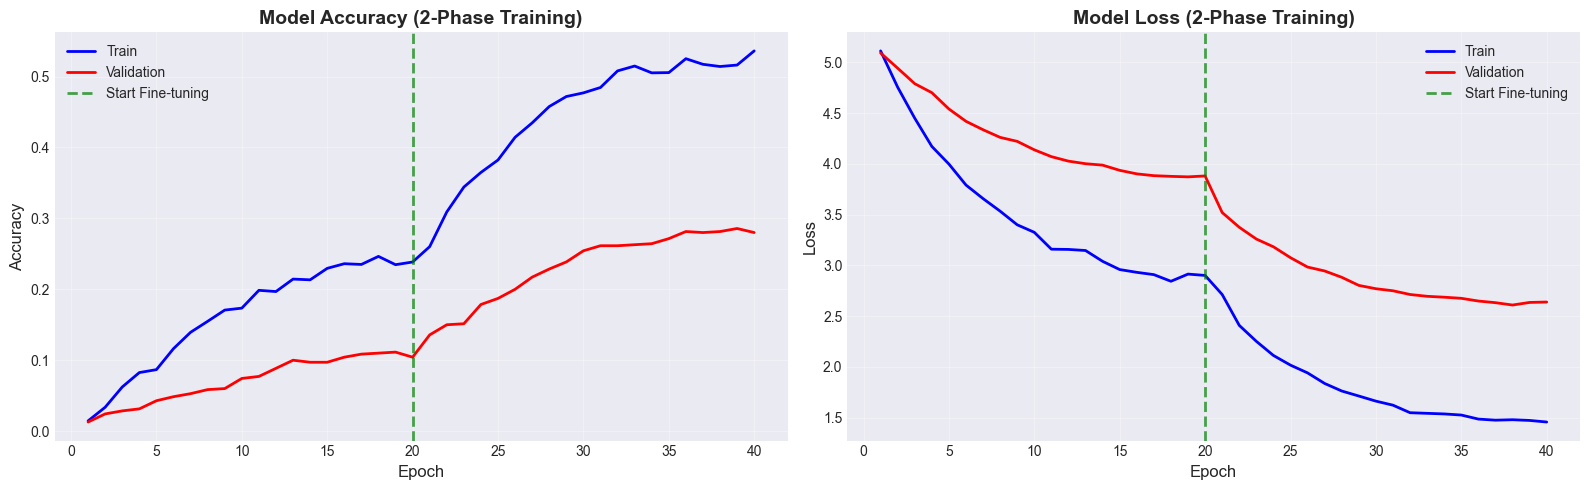

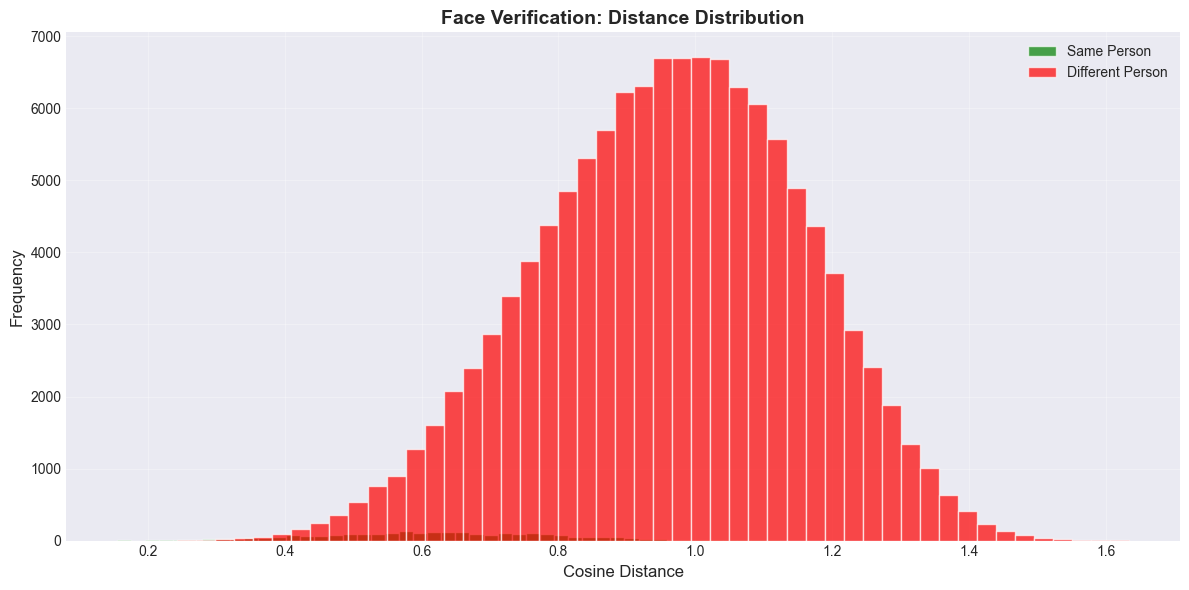

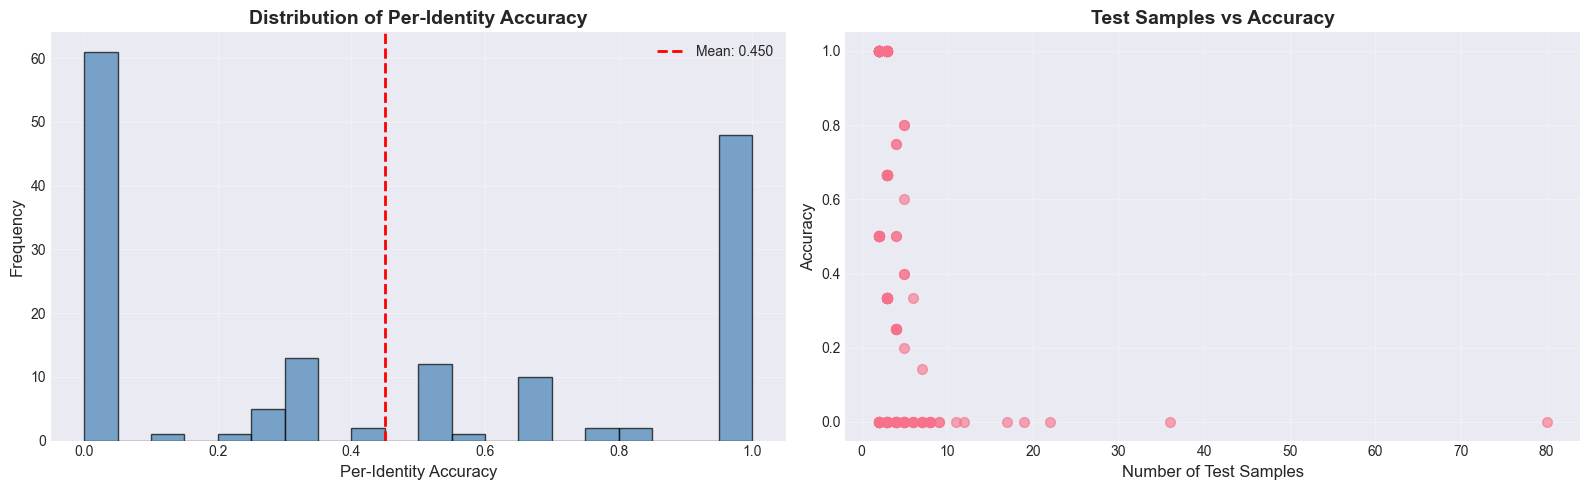


Model saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models\face_pytorch.pth
Embeddings saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch\test_embeddings.npy
History saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch\training_history.csv
Model info saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch\model_info.json

ALL DONE
Test Accuracy: 26.32%
Top-5 Accuracy: 50.70%
Total Training Time: 6.0 minutes
Model saved to: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models
Results saved to: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
from datetime import datetime
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image as PILImage

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_class_weight

try:
    from IPython.display import clear_output
    JUPYTER_MODE = True
except:
    JUPYTER_MODE = False

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


class FaceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        image = (image * 255).astype(np.uint8)
        image = PILImage.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image, label


class FaceRecognitionNet(nn.Module):
    def __init__(self, num_classes, embedding_dim=512):
        super(FaceRecognitionNet, self).__init__()
        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.embedding = nn.Sequential(
            nn.Linear(num_features, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(embedding_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, return_embedding=False):
        features = self.backbone(x)
        embeddings = self.embedding(features)
        embeddings_norm = nn.functional.normalize(embeddings, p=2, dim=1)
        if return_embedding:
            return embeddings_norm
        output = self.classifier(embeddings_norm)
        return output


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


def plot_training_progress(history_combined, phase1_epochs, results_dir, epoch_num):
    if JUPYTER_MODE:
        clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    epochs_range = range(1, len(history_combined['train_acc']) + 1)

    axes[0].plot(epochs_range, history_combined['train_acc'], 'b-', label='Train', linewidth=2)
    axes[0].plot(epochs_range, history_combined['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[0].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                    label='Start Fine-tuning', alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Model Accuracy (2-Phase Training)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history_combined['train_loss'], 'b-', label='Train', linewidth=2)
    axes[1].plot(epochs_range, history_combined['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                    label='Start Fine-tuning', alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Model Loss (2-Phase Training)', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(results_dir / 'training_progress_live.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nEpoch {epoch_num} Summary:")
    print(f"Train Acc: {history_combined['train_acc'][-1]*100:.2f}% | Val Acc: {history_combined['val_acc'][-1]*100:.2f}%")


def main():
    np.random.seed(42)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch: {torch.__version__}")
    print(f"Device: {device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"CUDA: {torch.version.cuda}")

    PROCESSED_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\data\processed\faces")
    MODELS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models")
    MODELS_DIR.mkdir(exist_ok=True)
    RESULTS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch")
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    BATCH_SIZE = 32
    EPOCHS_PHASE1 = 20
    EPOCHS_PHASE2 = 20
    LEARNING_RATE = 0.001
    FINETUNE_LR = 0.0001
    EMBEDDING_DIM = 512
    NUM_WORKERS = 0

    print(f"\nConfiguration:")
    print(f"  Device: {device}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Phase 1 epochs: {EPOCHS_PHASE1}")
    print(f"  Phase 2 epochs: {EPOCHS_PHASE2}")
    print(f"  Embedding dim: {EMBEDDING_DIM}")

    print("\n" + "="*70)
    print("LOADING DATA")
    print("="*70)

    X_train = np.load(PROCESSED_DIR / 'X_train.npy')
    y_train = np.load(PROCESSED_DIR / 'y_train.npy')
    X_val = np.load(PROCESSED_DIR / 'X_val.npy')
    y_val = np.load(PROCESSED_DIR / 'y_val.npy')
    X_test = np.load(PROCESSED_DIR / 'X_test.npy')
    y_test = np.load(PROCESSED_DIR / 'y_test.npy')

    with open(PROCESSED_DIR / 'label_mapping.pkl', 'rb') as f:
        label_mapping = pickle.load(f)

    NUM_CLASSES = label_mapping['num_classes']
    id_to_person = label_mapping['id_to_person']
    person_to_id = label_mapping['person_to_id']

    print(f"\nLoaded:")
    print(f"  Train: {X_train.shape}")
    print(f"  Val:   {X_val.shape}")
    print(f"  Test:  {X_test.shape}")
    print(f"  Identities: {NUM_CLASSES}")

    X_train = (X_train + 1) / 2
    X_val = (X_val + 1) / 2
    X_test = (X_test + 1) / 2

    print(f"Data rescaled to [0, 1]")

    train_counts = np.bincount(y_train)
    print(f"\nClass distribution:")
    print(f"  Min samples: {train_counts.min()}")
    print(f"  Max samples: {train_counts.max()}")
    print(f"  Mean samples: {train_counts.mean():.1f}")
    print(f"  Imbalance ratio: {train_counts.max() / train_counts.min():.1f}:1")

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.FloatTensor(class_weights).to(device)
    print(f"Using balanced class weights")

    sample_weights = np.array([class_weights[label].cpu() for label in y_train])
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomGrayscale(p=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
    val_dataset = FaceDataset(X_val, y_val, transform=val_transform)
    test_dataset = FaceDataset(X_test, y_test, transform=val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    print(f"\nData loaders created:")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}")
    print(f"  Using WeightedRandomSampler for balanced training")

    model = FaceRecognitionNet(num_classes=NUM_CLASSES, embedding_dim=EMBEDDING_DIM).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'='*70}")
    print(f"MODEL CREATED")
    print(f"{'='*70}")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Embedding dimension: {EMBEDDING_DIM}")
    print(f"{'='*70}")

    print(f"\n{'='*70}")
    print(f"PHASE 1: TRAINING WITH FROZEN BACKBONE")
    print(f"{'='*70}")

    for param in model.backbone.parameters():
        param.requires_grad = False

    trainable_params_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params_p1:,}")

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PHASE1, eta_min=1e-6)

    history_p1 = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc_p1 = 0.0
    start_time_p1 = datetime.now()

    for epoch in range(EPOCHS_PHASE1):
        print(f"\nPhase 1 - Epoch {epoch+1}/{EPOCHS_PHASE1}")
        print("-" * 70)

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        history_p1['train_loss'].append(train_loss)
        history_p1['train_acc'].append(train_acc)
        history_p1['val_loss'].append(val_loss)
        history_p1['val_acc'].append(val_acc)

        print(f"\nResults:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

        if val_acc > best_val_acc_p1:
            best_val_acc_p1 = val_acc
            print(f"  Best model (Phase 1)")

        if epoch % 3 == 0:
            history_combined = {
                'train_loss': history_p1['train_loss'],
                'train_acc': history_p1['train_acc'],
                'val_loss': history_p1['val_loss'],
                'val_acc': history_p1['val_acc']
            }
            plot_training_progress(history_combined, EPOCHS_PHASE1, RESULTS_DIR, epoch+1)

    time_p1 = (datetime.now() - start_time_p1).total_seconds() / 60
    print(f"\nPhase 1 complete: {time_p1:.1f} min, Best val acc: {best_val_acc_p1*100:.2f}%")

    print(f"\n{'='*70}")
    print(f"PHASE 2: FINE-TUNING")
    print(f"{'='*70}")

    for param in model.backbone.parameters():
        param.requires_grad = True

    trainable_params_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params_p2:,}")

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=FINETUNE_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PHASE2, eta_min=1e-7)

    history_p2 = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc_p2 = best_val_acc_p1
    patience = 10
    patience_counter = 0
    start_time_p2 = datetime.now()

    for epoch in range(EPOCHS_PHASE2):
        print(f"\nPhase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2}")
        print("-" * 70)

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        history_p2['train_loss'].append(train_loss)
        history_p2['train_acc'].append(train_acc)
        history_p2['val_loss'].append(val_loss)
        history_p2['val_acc'].append(val_acc)

        print(f"\nResults:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

        if val_acc > best_val_acc_p2:
            best_val_acc_p2 = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc,
                'epoch': epoch
            }, MODELS_DIR / 'face_pytorch_best.pth')
            print(f"  Best model saved (Val Acc: {val_acc*100:.2f}%)")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered")
            break

        if epoch % 3 == 0:
            history_combined = {
                'train_loss': history_p1['train_loss'] + history_p2['train_loss'],
                'train_acc': history_p1['train_acc'] + history_p2['train_acc'],
                'val_loss': history_p1['val_loss'] + history_p2['val_loss'],
                'val_acc': history_p1['val_acc'] + history_p2['val_acc']
            }
            plot_training_progress(history_combined, EPOCHS_PHASE1, RESULTS_DIR, EPOCHS_PHASE1 + epoch + 1)

    time_p2 = (datetime.now() - start_time_p2).total_seconds() / 60
    total_time = time_p1 + time_p2

    print(f"\nPhase 2 complete: {time_p2:.1f} min")
    print(f"Total training time: {total_time:.1f} minutes")
    print(f"Best val accuracy: {best_val_acc_p2*100:.2f}%")

    print(f"\n{'='*70}")
    print(f"EVALUATION")
    print(f"{'='*70}")

    checkpoint = torch.load(MODELS_DIR / 'face_pytorch_best.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model")
    print(f"Val accuracy: {checkpoint['val_acc']*100:.2f}%")

    print(f"\nEvaluating on test set...")
    test_loss, test_acc = validate(model, test_loader, criterion, device)

    print(f"\n{'='*70}")
    print(f"TEST SET RESULTS")
    print(f"{'='*70}")
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Predicting'):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    top5_correct = sum(
        all_labels[i] in np.argsort(all_probs[i])[-5:]
        for i in range(len(all_labels))
    )
    top5_acc = top5_correct / len(all_labels)

    print(f"Top-5 Accuracy: {top5_acc:.4f} ({top5_acc*100:.2f}%)")
    print(f"{'='*70}")

    print(f"\nExtracting embeddings for test set...")
    model.eval()
    test_embeddings = []

    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc='Extracting'):
            images = images.to(device)
            embeddings = model(images, return_embedding=True)
            test_embeddings.extend(embeddings.cpu().numpy())

    test_embeddings = np.array(test_embeddings)
    print(f"Embeddings extracted: {test_embeddings.shape}")

    print(f"\nComputing verification statistics...")
    n_samples = min(500, len(test_embeddings))
    sample_indices = np.random.choice(len(test_embeddings), n_samples, replace=False)

    same_person_distances = []
    diff_person_distances = []

    for i in range(len(sample_indices)):
        for j in range(i+1, len(sample_indices)):
            idx1, idx2 = sample_indices[i], sample_indices[j]

            dist = 1 - cosine_similarity(
                test_embeddings[idx1:idx1+1],
                test_embeddings[idx2:idx2+1]
            )[0][0]

            if all_labels[idx1] == all_labels[idx2]:
                same_person_distances.append(dist)
            else:
                diff_person_distances.append(dist)

    print(f"\nFace Verification Statistics:")
    print(f"  Same person - Mean: {np.mean(same_person_distances):.4f}")
    print(f"  Different person - Mean: {np.mean(diff_person_distances):.4f}")
    print(f"  Separation: {np.mean(diff_person_distances) - np.mean(same_person_distances):.4f}")

    unique_ids = np.unique(all_labels)
    per_identity_acc = []
    per_identity_count = []

    for person_id in unique_ids:
        mask = all_labels == person_id
        acc = accuracy_score(all_labels[mask], all_preds[mask])
        count = mask.sum()
        per_identity_acc.append(acc)
        per_identity_count.append(count)

    print(f"\nPer-Identity Statistics:")
    print(f"  Mean accuracy: {np.mean(per_identity_acc):.4f}")
    print(f"  Median accuracy: {np.median(per_identity_acc):.4f}")
    print(f"  Min accuracy: {np.min(per_identity_acc):.4f}")
    print(f"  Max accuracy: {np.max(per_identity_acc):.4f}")

    history_combined = {
        'train_loss': history_p1['train_loss'] + history_p2['train_loss'],
        'train_acc': history_p1['train_acc'] + history_p2['train_acc'],
        'val_loss': history_p1['val_loss'] + history_p2['val_loss'],
        'val_acc': history_p1['val_acc'] + history_p2['val_acc']
    }

    phase1_epochs = len(history_p1['train_acc'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    epochs_range = range(1, len(history_combined['train_acc']) + 1)

    axes[0].plot(epochs_range, history_combined['train_acc'], 'b-', label='Train', linewidth=2)
    axes[0].plot(epochs_range, history_combined['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[0].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                    label='Start Fine-tuning', alpha=0.7)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Model Accuracy (2-Phase Training)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history_combined['train_loss'], 'b-', label='Train', linewidth=2)
    axes[1].plot(epochs_range, history_combined['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[1].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                    label='Start Fine-tuning', alpha=0.7)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Model Loss (2-Phase Training)', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(same_person_distances, bins=50, alpha=0.7, label='Same Person', color='green')
    ax.hist(diff_person_distances, bins=50, alpha=0.7, label='Different Person', color='red')
    ax.set_xlabel('Cosine Distance', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Face Verification: Distance Distribution', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'verification_distances.png', dpi=300, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].hist(per_identity_acc, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].axvline(np.mean(per_identity_acc), color='red', linestyle='--',
                    linewidth=2, label=f'Mean: {np.mean(per_identity_acc):.3f}')
    axes[0].set_xlabel('Per-Identity Accuracy', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution of Per-Identity Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].scatter(per_identity_count, per_identity_acc, alpha=0.6, s=50)
    axes[1].set_xlabel('Number of Test Samples', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Test Samples vs Accuracy', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'per_identity_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    torch.save(model.state_dict(), MODELS_DIR / 'face_pytorch.pth')
    print(f"\nModel saved: {MODELS_DIR / 'face_pytorch.pth'}")

    np.save(RESULTS_DIR / 'test_embeddings.npy', test_embeddings)
    print(f"Embeddings saved: {RESULTS_DIR / 'test_embeddings.npy'}")

    history_df = pd.DataFrame(history_combined)
    history_df.to_csv(RESULTS_DIR / 'training_history.csv', index=False)
    print(f"History saved: {RESULTS_DIR / 'training_history.csv'}")

    model_info = {
        'model_name': 'FaceRecognitionNet PyTorch',
        'architecture': 'EfficientNet-B0 + Embeddings',
        'parameters': int(total_params),
        'num_classes': NUM_CLASSES,
        'embedding_dim': EMBEDDING_DIM,
        'training': {
            'phase1_epochs': EPOCHS_PHASE1,
            'phase2_epochs': len(history_p2['train_acc']),
            'total_epochs': len(history_combined['train_acc']),
            'batch_size': BATCH_SIZE,
            'phase1_time_minutes': float(time_p1),
            'phase2_time_minutes': float(time_p2),
            'total_time_minutes': float(total_time),
            'used_class_weights': True,
            'used_weighted_sampler': True,
        },
        'performance': {
            'best_val_acc': float(best_val_acc_p2),
            'test_acc': float(test_acc),
            'top5_acc': float(top5_acc),
            'test_loss': float(test_loss),
            'mean_per_identity_acc': float(np.mean(per_identity_acc)),
        },
        'verification': {
            'same_person_mean_dist': float(np.mean(same_person_distances)),
            'diff_person_mean_dist': float(np.mean(diff_person_distances)),
            'separation': float(np.mean(diff_person_distances) - np.mean(same_person_distances))
        },
        'label_mapping': {
            'num_classes': NUM_CLASSES,
            'id_to_person': id_to_person
        },
        'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    with open(RESULTS_DIR / 'model_info.json', 'w') as f:
        json.dump(model_info, f, indent=4)
    print(f"Model info saved: {RESULTS_DIR / 'model_info.json'}")

    print(f"\n{'='*70}")
    print(f"ALL DONE")
    print(f"{'='*70}")
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Top-5 Accuracy: {top5_acc*100:.2f}%")
    print(f"Total Training Time: {total_time:.1f} minutes")
    print(f"Model saved to: {MODELS_DIR}")
    print(f"Results saved to: {RESULTS_DIR}")
    print(f"{'='*70}")


if __name__ == '__main__':
    main()

PyTorch: 2.8.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA: 12.8

Configuration:
  Device: cuda
  Batch size: 32
  Phase 1 epochs: 50
  Phase 2 epochs: 50
  Embedding dim: 512

LOADING DATA

Loaded:
  Train: (2906, 160, 160, 3)
  Val:   (700, 160, 160, 3)
  Test:  (718, 160, 160, 3)
  Identities: 158
  Value range: [-1.00, 1.00]
Data rescaled to [0, 1]

Data loaders created:
  Train batches: 91
  Val batches: 22
  Test batches: 23

MODEL CREATED
Total parameters: 5,100,570
Trainable parameters: 5,100,570
Embedding dimension: 512

PHASE 1: TRAINING WITH FROZEN BACKBONE
Trainable parameters: 1,093,022

Phase 1 - Epoch 1/50
----------------------------------------------------------------------


Validation: 100%|██████████| 22/22 [00:00<00:00, 33.29it/s]



Results:
  Train Loss: 4.6828 | Train Acc: 12.84%
  Val Loss:   4.3739 | Val Acc:   16.29%
  Best model (Phase 1)

Phase 1 - Epoch 2/50
----------------------------------------------------------------------


Validation: 100%|██████████| 22/22 [00:00<00:00, 35.05it/s]



Results:
  Train Loss: 4.2038 | Train Acc: 18.34%
  Val Loss:   4.0599 | Val Acc:   19.71%
  Best model (Phase 1)

Phase 1 - Epoch 3/50
----------------------------------------------------------------------


...


TEST SET RESULTS
Test Loss:     0.7393
Test Accuracy: 0.8203 (82.03%)


Predicting: 100%|██████████| 23/23 [00:00<00:00, 34.05it/s]


Top-5 Accuracy: 0.9415 (94.15%)

Extracting embeddings for test set...


Extracting: 100%|██████████| 23/23 [00:00<00:00, 36.19it/s]


Embeddings extracted: (718, 512)

Computing verification statistics...

Face Verification Statistics:
  Same person - Mean: 0.4434
  Different person - Mean: 0.9978
  Separation: 0.5544

Per-Identity Statistics:
  Mean accuracy: 0.7028
  Median accuracy: 0.8571
  Min accuracy: 0.0000
  Max accuracy: 1.0000


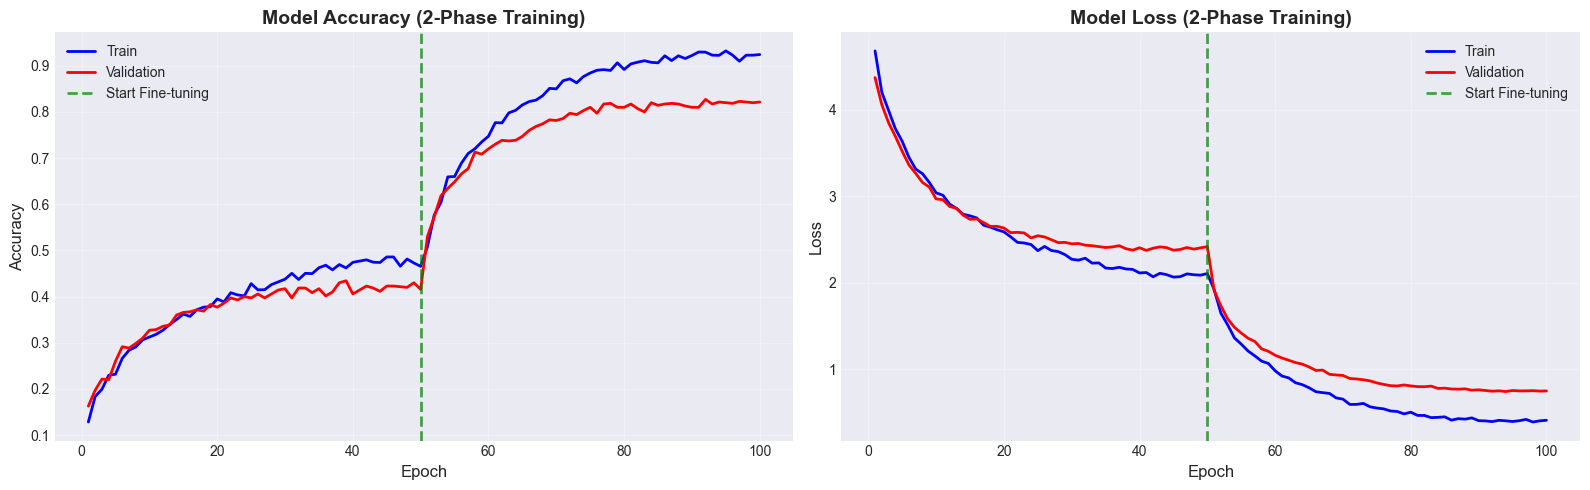

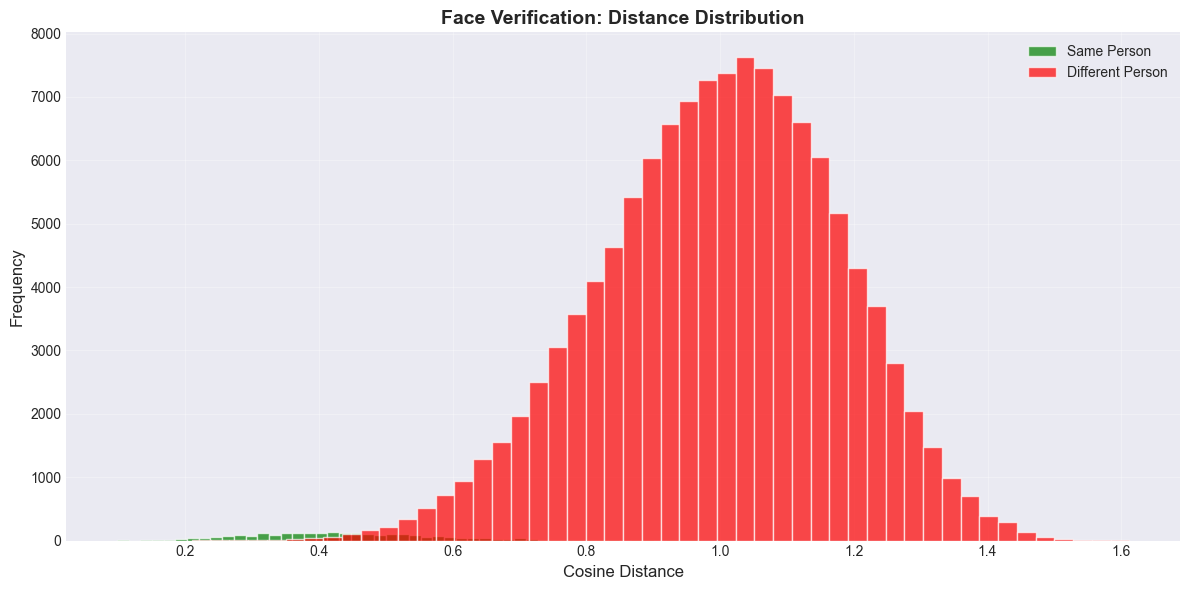

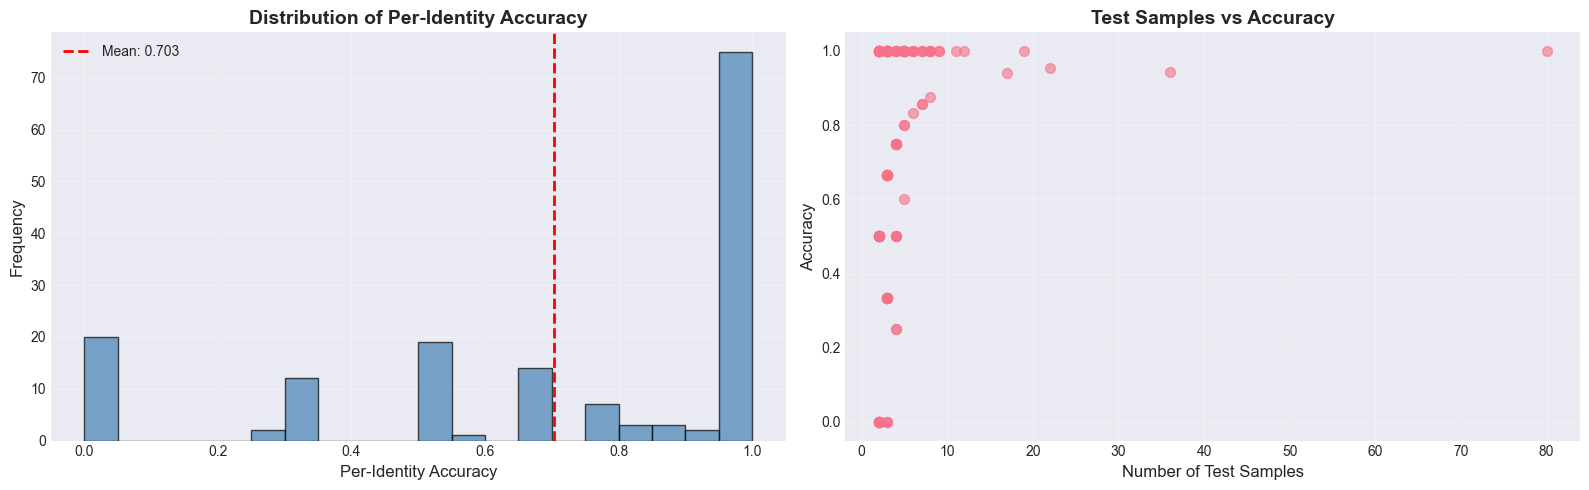


Model saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models\face_pytorch.pth
Embeddings saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch_1\test_embeddings.npy
History saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch_1\training_history.csv
Model info saved: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch_1\model_info.json

DONE
Test Accuracy: 82.03%
Top-5 Accuracy: 94.15%
Total Training Time: 13.4 minutes
Model saved to: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models
Results saved to: C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch_1


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
from datetime import datetime
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image as PILImage

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")

PROCESSED_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\data\processed\faces")
MODELS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\models")
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path(r"C:\Users\MSI GF66\OneDrive - National Polyechnic University of Armenia\Desktop\Emotion_recognition\results\face_pytorch_1")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
EPOCHS_PHASE1 = 50
EPOCHS_PHASE2 = 50
LEARNING_RATE = 0.001
FINETUNE_LR = 0.0001
EMBEDDING_DIM = 512

print(f"\nConfiguration:")
print(f"  Device: {device}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Phase 1 epochs: {EPOCHS_PHASE1}")
print(f"  Phase 2 epochs: {EPOCHS_PHASE2}")
print(f"  Embedding dim: {EMBEDDING_DIM}")

print("\n" + "="*70)
print("LOADING DATA")
print("="*70)

X_train = np.load(PROCESSED_DIR / 'X_train.npy')
y_train = np.load(PROCESSED_DIR / 'y_train.npy').astype(np.int64)
X_val = np.load(PROCESSED_DIR / 'X_val.npy')
y_val = np.load(PROCESSED_DIR / 'y_val.npy').astype(np.int64)
X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy').astype(np.int64)

with open(PROCESSED_DIR / 'label_mapping.pkl', 'rb') as f:
    label_mapping = pickle.load(f)

NUM_CLASSES = label_mapping['num_classes']
id_to_person = label_mapping['id_to_person']
person_to_id = label_mapping['person_to_id']

print(f"\nLoaded:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")
print(f"  Identities: {NUM_CLASSES}")
print(f"  Value range: [{X_train.min():.2f}, {X_train.max():.2f}]")

X_train = (X_train + 1) / 2
X_val = (X_val + 1) / 2
X_test = (X_test + 1) / 2

print(f"Data rescaled to [0, 1]")

class FaceDataset(Dataset):

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        image = (image * 255).astype(np.uint8)
        image = PILImage.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
val_dataset = FaceDataset(X_val, y_val, transform=val_transform)
test_dataset = FaceDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nData loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

class FaceRecognitionNet(nn.Module):

    def __init__(self, num_classes, embedding_dim=512):
        super(FaceRecognitionNet, self).__init__()

        self.backbone = models.efficientnet_b0(weights='DEFAULT')

        num_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Identity()

        self.embedding = nn.Sequential(
            nn.Linear(num_features, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(embedding_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x, return_embedding=False):
        features = self.backbone(x)
        embeddings = self.embedding(features)
        embeddings_norm = nn.functional.normalize(embeddings, p=2, dim=1)

        if return_embedding:
            return embeddings_norm

        output = self.classifier(embeddings_norm)

        return output

model = FaceRecognitionNet(num_classes=NUM_CLASSES, embedding_dim=EMBEDDING_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n{'='*70}")
print(f"MODEL CREATED")
print(f"{'='*70}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Embedding dimension: {EMBEDDING_DIM}")
print(f"{'='*70}")

print(f"\n{'='*70}")
print(f"PHASE 1: TRAINING WITH FROZEN BACKBONE")
print(f"{'='*70}")

for param in model.backbone.parameters():
    param.requires_grad = False

trainable_params_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params_p1:,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PHASE1, eta_min=1e-6)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total

history_p1 = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc_p1 = 0.0
start_time_p1 = datetime.now()

for epoch in range(EPOCHS_PHASE1):
    print(f"\nPhase 1 - Epoch {epoch+1}/{EPOCHS_PHASE1}")
    print("-" * 70)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()

    history_p1['train_loss'].append(train_loss)
    history_p1['train_acc'].append(train_acc)
    history_p1['val_loss'].append(val_loss)
    history_p1['val_acc'].append(val_acc)

    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

    if val_acc > best_val_acc_p1:
        best_val_acc_p1 = val_acc
        print(f"  Best model (Phase 1)")

time_p1 = (datetime.now() - start_time_p1).total_seconds() / 60
print(f"\nPhase 1 complete. Time: {time_p1:.1f} min, Best val acc: {best_val_acc_p1*100:.2f}%")

print(f"\n{'='*70}")
print(f"PHASE 2: FINE-TUNING")
print(f"{'='*70}")

for param in model.backbone.parameters():
    param.requires_grad = True

trainable_params_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params_p2:,}")

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=FINETUNE_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PHASE2, eta_min=1e-7)

history_p2 = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc_p2 = best_val_acc_p1
patience = 12
patience_counter = 0
start_time_p2 = datetime.now()

for epoch in range(EPOCHS_PHASE2):
    print(f"\nPhase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2}")
    print("-" * 70)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()

    history_p2['train_loss'].append(train_loss)
    history_p2['train_acc'].append(train_acc)
    history_p2['val_loss'].append(val_loss)
    history_p2['val_acc'].append(val_acc)

    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

    if val_acc > best_val_acc_p2:
        best_val_acc_p2 = val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'epoch': epoch
        }, MODELS_DIR / 'face_pytorch_best.pth')
        print(f"  Best model saved (Val Acc: {val_acc*100:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered")
        break

time_p2 = (datetime.now() - start_time_p2).total_seconds() / 60
total_time = time_p1 + time_p2

print(f"\nPhase 2 complete. Time: {time_p2:.1f} min")
print(f"Total training time: {total_time:.1f} minutes")
print(f"Best val accuracy: {best_val_acc_p2*100:.2f}%")

print(f"\n{'='*70}")
print(f"EVALUATION")
print(f"{'='*70}")

checkpoint = torch.load(MODELS_DIR / 'face_pytorch_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model")
print(f"Val accuracy: {checkpoint['val_acc']*100:.2f}%")

print(f"\nEvaluating on test set...")
test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"\n{'='*70}")
print(f"TEST SET RESULTS")
print(f"{'='*70}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Predicting'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

top5_correct = sum(
    all_labels[i] in np.argsort(all_probs[i])[-5:]
    for i in range(len(all_labels))
)
top5_acc = top5_correct / len(all_labels)

print(f"Top-5 Accuracy: {top5_acc:.4f} ({top5_acc*100:.2f}%)")
print(f"{'='*70}")

print(f"\nExtracting embeddings for test set...")
model.eval()
test_embeddings = []

with torch.no_grad():
    for images, _ in tqdm(test_loader, desc='Extracting'):
        images = images.to(device)
        embeddings = model(images, return_embedding=True)
        test_embeddings.extend(embeddings.cpu().numpy())

test_embeddings = np.array(test_embeddings)
print(f"Embeddings extracted: {test_embeddings.shape}")

print(f"\nComputing verification statistics...")
n_samples = min(500, len(test_embeddings))
sample_indices = np.random.choice(len(test_embeddings), n_samples, replace=False)

same_person_distances = []
diff_person_distances = []

for i in range(len(sample_indices)):
    for j in range(i+1, len(sample_indices)):
        idx1, idx2 = sample_indices[i], sample_indices[j]

        dist = 1 - cosine_similarity(
            test_embeddings[idx1:idx1+1],
            test_embeddings[idx2:idx2+1]
        )[0][0]

        if all_labels[idx1] == all_labels[idx2]:
            same_person_distances.append(dist)
        else:
            diff_person_distances.append(dist)

print(f"\nFace Verification Statistics:")
print(f"  Same person - Mean: {np.mean(same_person_distances):.4f}")
print(f"  Different person - Mean: {np.mean(diff_person_distances):.4f}")
print(f"  Separation: {np.mean(diff_person_distances) - np.mean(same_person_distances):.4f}")

unique_ids = np.unique(all_labels)
per_identity_acc = []
per_identity_count = []

for person_id in unique_ids:
    mask = all_labels == person_id
    acc = accuracy_score(all_labels[mask], all_preds[mask])
    count = mask.sum()
    per_identity_acc.append(acc)
    per_identity_count.append(count)

print(f"\nPer-Identity Statistics:")
print(f"  Mean accuracy: {np.mean(per_identity_acc):.4f}")
print(f"  Median accuracy: {np.median(per_identity_acc):.4f}")
print(f"  Min accuracy: {np.min(per_identity_acc):.4f}")
print(f"  Max accuracy: {np.max(per_identity_acc):.4f}")

history_combined = {
    'train_loss': history_p1['train_loss'] + history_p2['train_loss'],
    'train_acc': history_p1['train_acc'] + history_p2['train_acc'],
    'val_loss': history_p1['val_loss'] + history_p2['val_loss'],
    'val_acc': history_p1['val_acc'] + history_p2['val_acc']
}

phase1_epochs = len(history_p1['train_acc'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, len(history_combined['train_acc']) + 1)

axes[0].plot(epochs_range, history_combined['train_acc'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs_range, history_combined['val_acc'], 'r-', label='Validation', linewidth=2)
axes[0].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                label='Start Fine-tuning', alpha=0.7)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy (2-Phase Training)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_combined['train_loss'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs_range, history_combined['val_loss'], 'r-', label='Validation', linewidth=2)
axes[1].axvline(x=phase1_epochs, color='green', linestyle='--', linewidth=2,
                label='Start Fine-tuning', alpha=0.7)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss (2-Phase Training)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(same_person_distances, bins=50, alpha=0.7, label='Same Person', color='green')
ax.hist(diff_person_distances, bins=50, alpha=0.7, label='Different Person', color='red')
ax.set_xlabel('Cosine Distance', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Face Verification: Distance Distribution', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'verification_distances.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(per_identity_acc, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(per_identity_acc), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(per_identity_acc):.3f}')
axes[0].set_xlabel('Per-Identity Accuracy', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Per-Identity Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(per_identity_count, per_identity_acc, alpha=0.6, s=50)
axes[1].set_xlabel('Number of Test Samples', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Test Samples vs Accuracy', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_identity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

torch.save(model.state_dict(), MODELS_DIR / 'face_pytorch.pth')
print(f"\nModel saved: {MODELS_DIR / 'face_pytorch.pth'}")

np.save(RESULTS_DIR / 'test_embeddings.npy', test_embeddings)
print(f"Embeddings saved: {RESULTS_DIR / 'test_embeddings.npy'}")

history_df = pd.DataFrame(history_combined)
history_df.to_csv(RESULTS_DIR / 'training_history.csv', index=False)
print(f"History saved: {RESULTS_DIR / 'training_history.csv'}")

model_info = {
    'model_name': 'FaceRecognitionNet PyTorch',
    'architecture': 'EfficientNet-B0 + Embeddings',
    'parameters': int(total_params),
    'num_classes': NUM_CLASSES,
    'embedding_dim': EMBEDDING_DIM,
    'training': {
        'phase1_epochs': EPOCHS_PHASE1,
        'phase2_epochs': len(history_p2['train_acc']),
        'total_epochs': len(history_combined['train_acc']),
        'batch_size': BATCH_SIZE,
        'phase1_time_minutes': float(time_p1),
        'phase2_time_minutes': float(time_p2),
        'total_time_minutes': float(total_time),
    },
    'performance': {
        'best_val_acc': float(best_val_acc_p2),
        'test_acc': float(test_acc),
        'top5_acc': float(top5_acc),
        'test_loss': float(test_loss),
        'mean_per_identity_acc': float(np.mean(per_identity_acc)),
    },
    'verification': {
        'same_person_mean_dist': float(np.mean(same_person_distances)),
        'diff_person_mean_dist': float(np.mean(diff_person_distances)),
        'separation': float(np.mean(diff_person_distances) - np.mean(same_person_distances))
    },
    'label_mapping': {
        'num_classes': NUM_CLASSES,
        'id_to_person': id_to_person
    },
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open(RESULTS_DIR / 'model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print(f"Model info saved: {RESULTS_DIR / 'model_info.json'}")

print(f"\n{'='*70}")
print(f"DONE")
print(f"{'='*70}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Top-5 Accuracy: {top5_acc*100:.2f}%")
print(f"Total Training Time: {total_time:.1f} minutes")
print(f"Model saved to: {MODELS_DIR}")
print(f"Results saved to: {RESULTS_DIR}")
print(f"{'='*70}")